In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path = "../data/raw/Créditos_Otorgados._20260304.csv"
df = pd.read_csv(path, sep=None, engine='python') 

In [ ]:
print("-- dataset's info --")
print(df.info())


-- dataset's info --
<class 'pandas.DataFrame'>
RangeIndex: 107534 entries, 0 to 107533
Data columns (total 13 columns):
 #   Column                                     Non-Null Count   Dtype
---  ------                                     --------------   -----
 0   VIGENCIA                                   107534 non-null  str  
 1   PERIODO OTORGAMIENTO                       107534 non-null  str  
 2   SEXO AL NACER                              107534 non-null  str  
 3   ESTRATO SOCIOECONÓMICO                     107534 non-null  int64
 4   CÓDIGO DEDEPARTAMENTO DE ORIGEN            107534 non-null  int64
 5   DEPARTAMENTO DE ORIGEN                     107534 non-null  str  
 6   CATEGORÍA DEL MUNICIPIO DE ORIGEN          107534 non-null  str  
 7   SECTOR IES                                 98350 non-null   str  
 8   NIVEL DE FORMACIÓN                         107534 non-null  str  
 9   MODALIDAD DE LÍNEA                         107534 non-null  str  
 10  MODALIDAD DEL CRÉDITO 

In [6]:
print("\n--- DATA PREVIEW ---")
display(df.head())


--- DATA PREVIEW ---


,VIGENCIA,PERIODO OTORGAMIENTO,SEXO AL NACER,ESTRATO SOCIOECONÓMICO,CÓDIGO DEDEPARTAMENTO DE ORIGEN,DEPARTAMENTO DE ORIGEN,CATEGORÍA DEL MUNICIPIO DE ORIGEN,SECTOR IES,NIVEL DE FORMACIÓN,MODALIDAD DE LÍNEA,MODALIDAD DEL CRÉDITO,RANGO DEL VALOR TOTAL DESEMBOLSADO,NÚMERO DE NUEVOS BENEFICIARIOS DE CRÉDITO
0,"2,015",2015-1,Femenino,1,5,ANTIOQUIA,CIUDADES Y AGLOMERACIONES,OFICIAL,Formación técnica profesional,PREGRADO,MATRICULA,I,1
1,"2,015",2015-1,Femenino,1,5,ANTIOQUIA,CIUDADES Y AGLOMERACIONES,OFICIAL,Formación técnica profesional,PREGRADO,MATRICULA,IV,1
2,"2,015",2015-1,Femenino,1,5,ANTIOQUIA,CIUDADES Y AGLOMERACIONES,OFICIAL,Formación técnica profesional,PREGRADO,MATRICULA,V,2
3,"2,015",2015-1,Femenino,1,5,ANTIOQUIA,CIUDADES Y AGLOMERACIONES,OFICIAL,Tecnológico,PREGRADO,SOSTENIMIENTO,I,1
4,"2,015",2015-1,Femenino,1,5,ANTIOQUIA,CIUDADES Y AGLOMERACIONES,OFICIAL,Universitario,PREGRADO,MATRICULA,I,5


In [ ]:
print("\nNull data Analysis")
null_counts = df.isnull().sum()
null_percentages = (null_counts / len(df)) * 100
print(pd.DataFrame({'Null': null_counts, 'Percentage': null_percentages}))


--- ANÁLISIS DE NULOS ---
                                           Nulos  Porcentaje
VIGENCIA                                       0    0.000000
PERIODO OTORGAMIENTO                           0    0.000000
SEXO AL NACER                                  0    0.000000
ESTRATO SOCIOECONÓMICO                         0    0.000000
CÓDIGO DEDEPARTAMENTO DE ORIGEN                0    0.000000
DEPARTAMENTO DE ORIGEN                         0    0.000000
CATEGORÍA DEL MUNICIPIO DE ORIGEN              0    0.000000
SECTOR IES                                  9184    8.540555
NIVEL DE FORMACIÓN                             0    0.000000
MODALIDAD DE LÍNEA                             0    0.000000
MODALIDAD DEL CRÉDITO                          0    0.000000
RANGO DEL VALOR TOTAL DESEMBOLSADO             0    0.000000
NÚMERO DE NUEVOS BENEFICIARIOS DE CRÉDITO      0    0.000000


In [8]:
print(f"\nDuplicates: {df.duplicated().sum()}")


Duplicates: 0


In [9]:
print("--- DESCRIPTIVE STATISTICS ---")
display(df.describe())

--- DESCRIPTIVE STATISTICS ---


,ESTRATO SOCIOECONÓMICO,CÓDIGO DEDEPARTAMENTO DE ORIGEN,NÚMERO DE NUEVOS BENEFICIARIOS DE CRÉDITO
count,107534.000000,107534.000000,107534.000000
mean,2.306433,40.137017,4.648418
std,1.204165,26.598049,15.037565
min,1.000000,5.000000,1.000000
25%,1.000000,15.000000,1.000000
50%,2.000000,41.000000,1.000000
75%,3.000000,68.000000,3.000000
max,6.000000,99.000000,668.000000


In [10]:
# Identify unique values to detect inconsistencies (e.g., 'OFICIAL' vs 'Oficial')
categorical_targets = [
    'SEXO AL NACER', 'ESTRATO SOCIOECONÓMICO', 'SECTOR IES', 
    'NIVEL DE FORMACIÓN', 'MODALIDAD DEL CRÉDITO', 'RANGO DEL VALOR TOTAL DESEMBOLSADO'
]

for col in categorical_targets:
    print(f"\nUnique values for {col}:")
    print(df[col].unique())


Unique values for SEXO AL NACER:
<StringArray>
['Femenino', 'Masculino', 'Intersexual']
Length: 3, dtype: str

Unique values for ESTRATO SOCIOECONÓMICO:
[1 2 3 4 5 6]

Unique values for SECTOR IES:
<StringArray>
['OFICIAL', 'PRIVADO', nan]
Length: 3, dtype: str

Unique values for NIVEL DE FORMACIÓN:
<StringArray>
[      'Formación técnica profesional',                         'Tecnológico',
                       'Universitario',                            'Exterior',
       'Especialización universitaria',   'Especialización médico quirúrgica',
                            'Maestría',                           'Doctorado',
                          'Normalista',         'Especialización tecnológica',
 'Especialización técnico profesional']
Length: 11, dtype: str

Unique values for MODALIDAD DEL CRÉDITO:
<StringArray>
['MATRICULA', 'SOSTENIMIENTO', 'MI PC']
Length: 3, dtype: str

Unique values for RANGO DEL VALOR TOTAL DESEMBOLSADO:
<StringArray>
['I', 'IV', 'V', 'III', 'II']
Length: 5

<Figure size 1200x600 with 0 Axes>

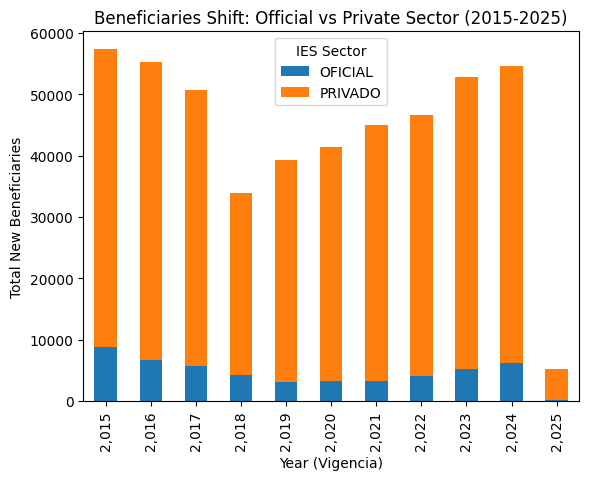

--- RAW TREND DATA ---


SECTOR IES,OFICIAL,PRIVADO
VIGENCIA,,
"2,015",8883,48512
"2,016",6737,48619
"2,017",5742,44964
"2,018",4302,29605
"2,019",3121,36146
"2,020",3259,38229
"2,021",3331,41751
"2,022",4133,42537
"2,023",5188,47584


In [11]:
# 'NÚMERO DE NUEVOS BENEFICIARIOS DE CRÉDITO' is our MEASURE
trend_analysis = df.groupby(['VIGENCIA', 'SECTOR IES'])['NÚMERO DE NUEVOS BENEFICIARIOS DE CRÉDITO'].sum().unstack()

plt.figure(figsize=(12, 6))
trend_analysis.plot(kind='bar', stacked=True)
plt.title('Beneficiaries Shift: Official vs Private Sector (2015-2025)')
plt.ylabel('Total New Beneficiaries')
plt.xlabel('Year (Vigencia)')
plt.legend(title='IES Sector')
plt.show()

print("--- RAW TREND DATA ---")
display(trend_analysis)

Upper Bound threshold: 6.0
Total Outliers detected: 13514 (12.57% of data)


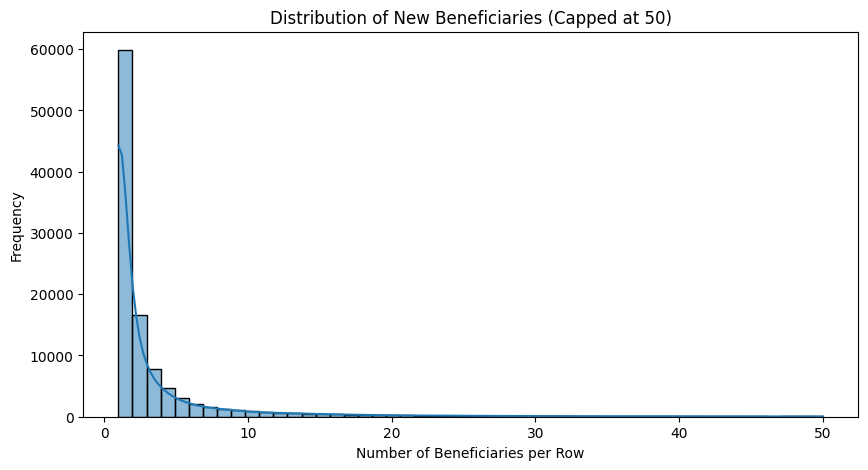

Records in VIGENCIA with formatting issues (commas): 107534


In [12]:
# --- ADVANCED PROFILING: OUTLIERS & DISTRIBUTIONS ---
import seaborn as sns
import matplotlib.pyplot as plt

# 1. IQR Method for outlier detection on our main measure
target_col = 'NÚMERO DE NUEVOS BENEFICIARIOS DE CRÉDITO'

Q1 = df[target_col].quantile(0.25)
Q3 = df[target_col].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

outliers = df[df[target_col] > upper_bound]
outlier_pct = (len(outliers) / len(df)) * 100

print(f"Upper Bound threshold: {upper_bound}")
print(f"Total Outliers detected: {len(outliers)} ({outlier_pct:.2f}% of data)")

# Note: In this business context, these "outliers" are not errors. 
# They represent mass enrollments, highly likely driven by public sector policies. 
# We don't delete them; we analyze them.

# 2. Distribution Plot (Visual proof of skewness)
plt.figure(figsize=(10, 5))
sns.histplot(df[df[target_col] <= 50][target_col], bins=50, kde=True) # Capped at 50 for readability
plt.title('Distribution of New Beneficiaries (Capped at 50)')
plt.xlabel('Number of Beneficiaries per Row')
plt.ylabel('Frequency')
plt.show()

# 3. Formatting Detection Check
# Checking if 'VIGENCIA' has commas explicitly
commas_found = df['VIGENCIA'].astype(str).str.contains(',').sum()
print(f"Records in VIGENCIA with formatting issues (commas): {commas_found}")

## Data Quality Assessment & Profiling Log

| Feature / Column | Issue Identified (Profiling) | Root Cause / Business Context | Transformation Rule (ETL Action) |
| :--- | :--- | :--- | :--- |
| `VIGENCIA` | **Inconsistent formatting:** Values contain commas (e.g., "2,015"). Casted as `object` (string) instead of integer. | Export formatting artifact from the open data portal. | Remove commas using `.str.replace(',', '')` and cast to `int64`. |
| `SECTOR IES` | **Missing Values:** 9,184 null records (8.54% of dataset). | Often missing when the credit is for foreign institutions ('Exterior') or non-traditional entities. | Impute missing values with 'NO CLASIFICADO' or derive from `NIVEL DE FORMACIÓN` if applicable. Do not drop to preserve total beneficiary count. |
| `NÚMERO DE NUEVOS BENEFICIARIOS...` | **Statistical Outliers:** 10,750 rows exceed the IQR upper bound (values up to 668). | These are not data errors. They represent large, grouped cohorts typical of public university block-enrollments. | Keep as valid data. Flagging is not required, but analysis must account for right-skewed distribution. |
| All String Columns | **Categorical Noise:** Potential trailing spaces or case mismatches (e.g., 'OFICIAL' vs 'Oficial'). | Manual data entry errors at the source (ICETEX forms). | Standardize all text columns: apply `.str.strip()` and `.str.upper()`. |